# Load Dataset

In [1]:
from PIL import Image
import os
import numpy as np

# Initialize lists for images and labels for original train and test sets
images_train = []
labels_train = []
images_test = []
labels_test = []

# Path to your dataset
data_dir = 'Dataset/tomato'

main_folders = ['train', 'test']

for main_folder in main_folders:
    main_folder_path = os.path.join(data_dir, main_folder)

    if not os.path.isdir(main_folder_path):
        print(f"Warning: Main folder not found: {main_folder_path}")
        continue

    print(f"Loading images from: {main_folder_path}")

    img_folders = os.listdir(main_folder_path)

    for img in img_folders:
        img_path = os.path.join(main_folder_path, img)

        if not os.path.isdir(img_path):
            continue

        for image_file in os.listdir(img_path):
            if image_file.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG')):
                image_path = os.path.join(img_path, image_file)
                try:  # Check corrupted files
                    image = Image.open(image_path)
                    image = image.convert("RGB")
                    image = image.resize((224, 224))

                    if main_folder == 'train':
                        images_train.append(np.array(image))
                        labels_train.append(img)
                    elif main_folder == 'test':
                        images_test.append(np.array(image))
                        labels_test.append(img)

                except Exception as e:
                    print(f"Error loading image {image_path}: {e}")

# Convert lists to numpy arrays
images_train = np.array(images_train)
labels_train = np.array(labels_train)
images_test = np.array(images_test)
labels_test = np.array(labels_test)

print(f"Loaded {len(images_train)} images for original training set.")
if len(images_train) > 0:
    print(f"Original Training Image shape: {images_train[0].shape}")
    print(f"Original Training Unique diseases: {np.unique(labels_train)}")
else:
    print("No images were loaded for the original training set.")

print(f"Loaded {len(images_test)} images for original test set.")
if len(images_test) > 0:
    print(f"Original Test Image shape: {images_test[0].shape}")
    print(f"Original Test Unique diseases: {np.unique(labels_test)}")
else:
    print("No images were loaded for the original test set.")

Loading images from: Dataset/tomato/train
Loading images from: Dataset/tomato/test
Loaded 5000 images for original training set.
Original Training Image shape: (224, 224, 3)
Original Training Unique diseases: ['Tomato___Bacterial_spot' 'Tomato___Early_blight' 'Tomato___Late_blight'
 'Tomato___Leaf_Mold' 'Tomato___Septoria_leaf_spot'
 'Tomato___Spider_mites Two-spotted_spider_mite' 'Tomato___Target_Spot'
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus' 'Tomato___Tomato_mosaic_virus'
 'Tomato___healthy']
Loaded 1000 images for original test set.
Original Test Image shape: (224, 224, 3)
Original Test Unique diseases: ['Tomato___Bacterial_spot' 'Tomato___Early_blight' 'Tomato___Late_blight'
 'Tomato___Leaf_Mold' 'Tomato___Septoria_leaf_spot'
 'Tomato___Spider_mites Two-spotted_spider_mite' 'Tomato___Target_Spot'
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus' 'Tomato___Tomato_mosaic_virus'
 'Tomato___healthy']


# EDA

In [2]:
import pandas as pd

# Convert labels to a pandas Series
labels_train_series = pd.Series(labels_train)
labels_test_series = pd.Series(labels_test)

# Count images per diseases on the training set
disease_counts_train = labels_train_series.value_counts()
disease_counts_test = labels_test_series.value_counts()

print("Image counts per diseases in the TRAINING set:")
print(disease_counts_train)
print(f"\nTotal images in TRAINING set: {disease_counts_train.sum()}")
print("Image counts per diseases in the TEST set:")
print(disease_counts_test)
print(f"\nTotal images in TEST set: {disease_counts_test.sum()}")

Image counts per diseases in the TRAINING set:
Tomato___Bacterial_spot                          500
Tomato___Early_blight                            500
Tomato___healthy                                 500
Tomato___Late_blight                             500
Tomato___Leaf_Mold                               500
Tomato___Septoria_leaf_spot                      500
Tomato___Spider_mites Two-spotted_spider_mite    500
Tomato___Target_Spot                             500
Tomato___Tomato_mosaic_virus                     500
Tomato___Tomato_Yellow_Leaf_Curl_Virus           500
Name: count, dtype: int64

Total images in TRAINING set: 5000
Image counts per diseases in the TEST set:
Tomato___Bacterial_spot                          100
Tomato___Early_blight                            100
Tomato___healthy                                 100
Tomato___Late_blight                             100
Tomato___Leaf_Mold                               100
Tomato___Septoria_leaf_spot                      100


In [3]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit the encoder on the training labels ONLY
label_encoder.fit(labels_train)

# Transform both training and test labels using the fitted encoder
encoded_labels_train = label_encoder.transform(labels_train)
encoded_labels_test = label_encoder.transform(labels_test)

# Get the mapping of original labels to encoded integers
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("Encoded training labels:")
print(encoded_labels_train[:])
print("Encoded test labels:")
print(encoded_labels_test[:])
print("Label mapping:")
print(label_mapping)
print(f"Number of classes: {len(label_encoder.classes_)}")

Encoded training labels:
[0 0 0 ... 7 7 7]
Encoded test labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
 9 9 9 9 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3

### Split Data and Preprocess Images

Before training a model, we need to split our data into training and validation sets. It's also good practice to normalize the image pixel values to a range like `[0, 1]`.

In [4]:
import torch
from sklearn.model_selection import train_test_split
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset, DataLoader

# Normalize original training images to a range of [0, 1]
images_train_normalized = images_train.astype('float32') / 255.0

# Train–Validation split from the ORIGINAL training data (images_train_normalized and encoded_labels_train)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    images_train_normalized,
    encoded_labels_train,
    test_size=0.2, # 20% of the original training data will be used for validation
    random_state=42,
    stratify=encoded_labels_train
)

# Normalize original test images to a range of [0, 1]
# These will be the final test set for model evaluation
X_test_np = images_test.astype('float32') / 255.0
y_test_np = encoded_labels_test

print(f"Shape of X_train: {X_train_np.shape}")
print(f"Shape of X_val: {X_val_np.shape}")
print(f"Shape of X_test: {X_test_np.shape}")
print(f"Shape of y_train: {y_train_np.shape}")
print(f"Shape of y_val: {y_val_np.shape}")
print(f"Shape of y_test: {y_test_np.shape}")
print(f"X_train data type: {X_train_np.dtype}")
print(f"y_train data type: {y_train_np.dtype}")

Shape of X_train: (4000, 224, 224, 3)
Shape of X_val: (1000, 224, 224, 3)
Shape of X_test: (1000, 224, 224, 3)
Shape of y_train: (4000,)
Shape of y_val: (1000,)
Shape of y_test: (1000,)
X_train data type: float32
y_train data type: int64


In [5]:
# Convert numpy arrays to PyTorch tensors and permute image dimensions for PyTorch (C, H, W)
X_train = torch.from_numpy(X_train_np).permute(0, 3, 1, 2).float()
X_val = torch.from_numpy(X_val_np).permute(0, 3, 1, 2).float()
X_test = torch.from_numpy(X_test_np).permute(0, 3, 1, 2).float()

y_train = torch.from_numpy(y_train_np).long()
y_val = torch.from_numpy(y_val_np).long()
y_test = torch.from_numpy(y_test_np).long()

We used `stratify=encoded_labels` to ensure that the class distribution in the training and validation sets is similar to the original dataset, which is important for imbalanced datasets, though in your case, the classes are well-balanced.

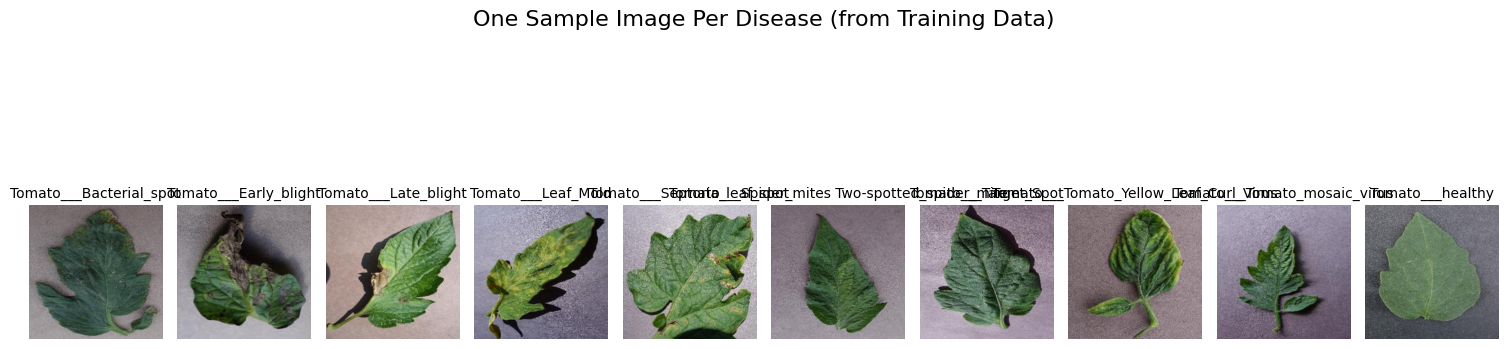

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique encoded labels and their original names from the training set
unique_encoded_labels = np.unique(encoded_labels_train)

# Create a reverse mapping from encoded labels to diseases names (from the global label_mapping)
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

# Set up the figure for plotting
num_diseases = len(unique_encoded_labels)
fig, axes = plt.subplots(1, num_diseases, figsize=(15, 5))

# Flatten axes array for easy iteration if there's only one row
if num_diseases == 1:
    axes = [axes]

for i, encoded_label in enumerate(unique_encoded_labels):
    # Find the index of the first image with this encoded label in the training set
    idx = np.where(encoded_labels_train == encoded_label)[0][0]

    # Get the image and its original disease name
    image_to_show = images_train_normalized[idx]
    disease_name = reverse_label_mapping[encoded_label]

    # Plot the image
    axes[i].imshow(image_to_show)
    axes[i].set_title(disease_name, fontsize=10)
    axes[i].axis('off') # Hide axes ticks and labels

plt.suptitle("One Sample Image Per Disease (from Training Data)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

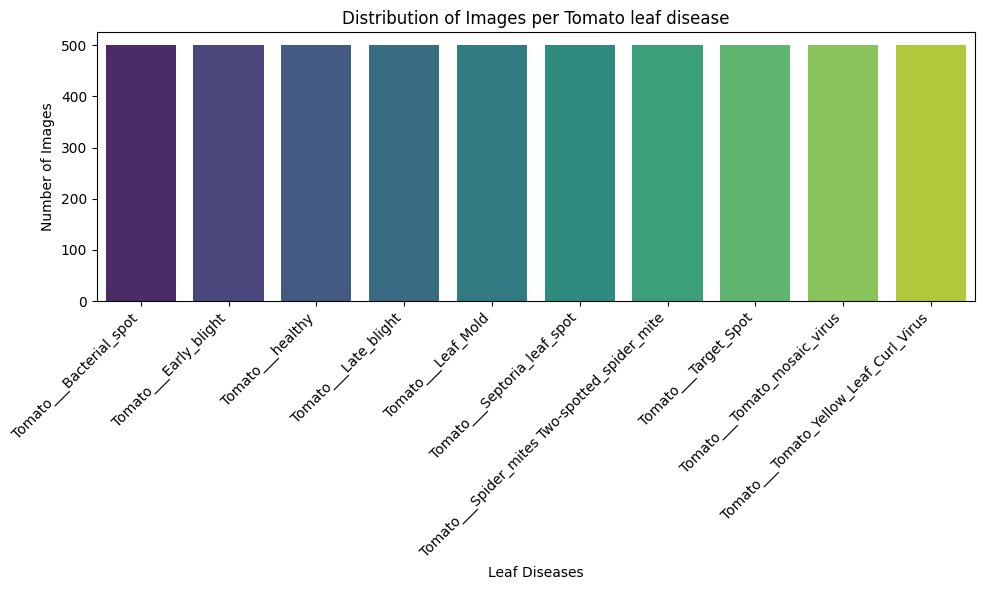

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot of the Leaf diseases
plt.figure(figsize=(10, 6))
sns.barplot(x=disease_counts_train.index, y=disease_counts_train.values, palette='viridis', hue=list(disease_counts_train.index))
plt.title('Distribution of Images per Tomato leaf disease')
plt.xlabel('Leaf Diseases')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This bar plot clearly shows the number of images available for each Leaf diseases in your dataset. As we observed earlier, the dataset is very well-balanced across all classes.

In [8]:
# Image dimension analysis
print("Image Dimension Analysis:")
print(f"Original training images shape: {images_train.shape}")
print(f"Original test images shape: {images_test.shape}")
print(f"Image dimensions (H x W x C): {images_train.shape[1]} x {images_train.shape[2]} x {images_train.shape[3]}")
print(f"\nPixel value statistics (before normalization):")
print(f"Min pixel value: {images_train.min()}")
print(f"Max pixel value: {images_train.max()}")
print(f"Mean pixel value: {images_train.mean():.2f}")
print(f"Std pixel value: {images_train.std():.2f}")

Image Dimension Analysis:
Original training images shape: (5000, 224, 224, 3)
Original test images shape: (1000, 224, 224, 3)
Image dimensions (H x W x C): 224 x 224 x 3

Pixel value statistics (before normalization):
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 113.27
Std pixel value: 46.12


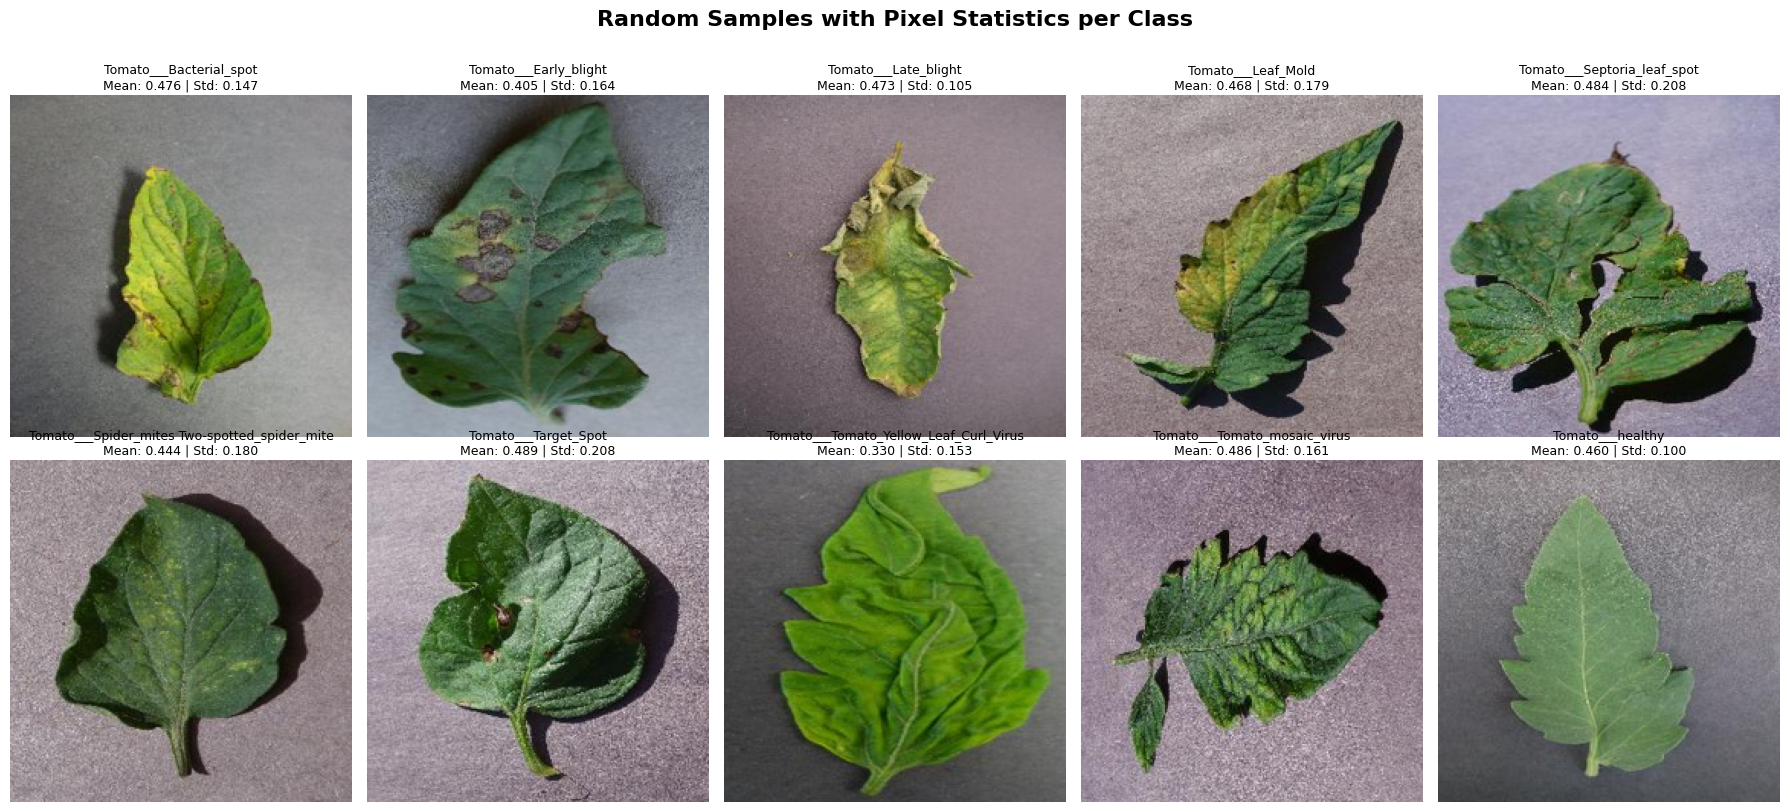

In [9]:
# Visualize random samples from each class with their statistics
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for idx, encoded_label in enumerate(unique_encoded_labels):
    # Get a random image from this class
    class_indices = np.where(encoded_labels_train == encoded_label)[0]
    random_idx = np.random.choice(class_indices)
    
    img = images_train_normalized[random_idx]
    disease_name = reverse_label_mapping[encoded_label]
    
    # Display image
    axes[idx].imshow(img)
    axes[idx].set_title(f"{disease_name}\nMean: {img.mean():.3f} | Std: {img.std():.3f}", 
                       fontsize=9, wrap=True)
    axes[idx].axis('off')

plt.suptitle("Random Samples with Pixel Statistics per Class", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

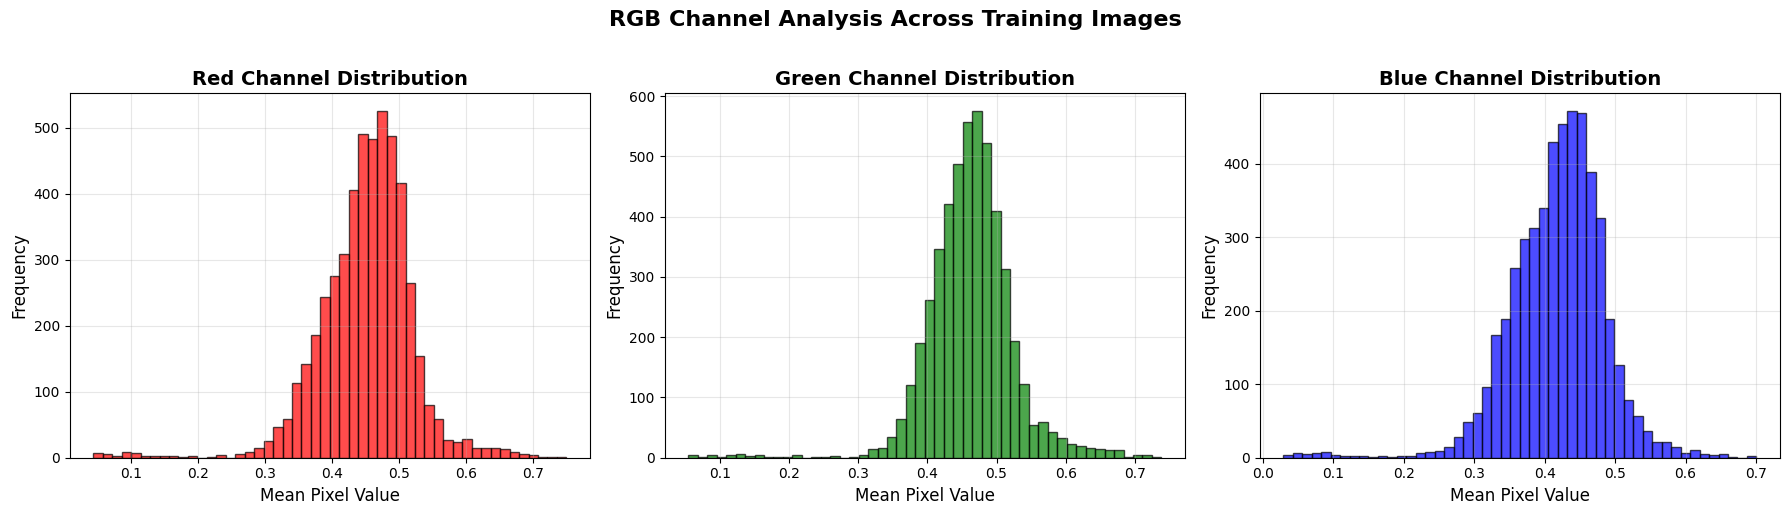

Red channel - Mean: 0.4519, Std: 0.0696
Green channel - Mean: 0.4625, Std: 0.0628
Blue channel - Mean: 0.4183, Std: 0.0685


In [10]:
# RGB channel analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate mean RGB values across all training images
mean_r = images_train_normalized[:, :, :, 0].mean(axis=(1, 2))
mean_g = images_train_normalized[:, :, :, 1].mean(axis=(1, 2))
mean_b = images_train_normalized[:, :, :, 2].mean(axis=(1, 2))

# Red channel distribution
axes[0].hist(mean_r, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Red Channel Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mean Pixel Value', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(alpha=0.3)

# Green channel distribution
axes[1].hist(mean_g, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('Green Channel Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean Pixel Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(alpha=0.3)

# Blue channel distribution
axes[2].hist(mean_b, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[2].set_title('Blue Channel Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Mean Pixel Value', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].grid(alpha=0.3)

plt.suptitle('RGB Channel Analysis Across Training Images', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red channel - Mean: {mean_r.mean():.4f}, Std: {mean_r.std():.4f}")
print(f"Green channel - Mean: {mean_g.mean():.4f}, Std: {mean_g.std():.4f}")
print(f"Blue channel - Mean: {mean_b.mean():.4f}, Std: {mean_b.std():.4f}")

/tmp/ipykernel_19702/530992239.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(box_data, labels=brightness_by_class.keys(), patch_artist=True)


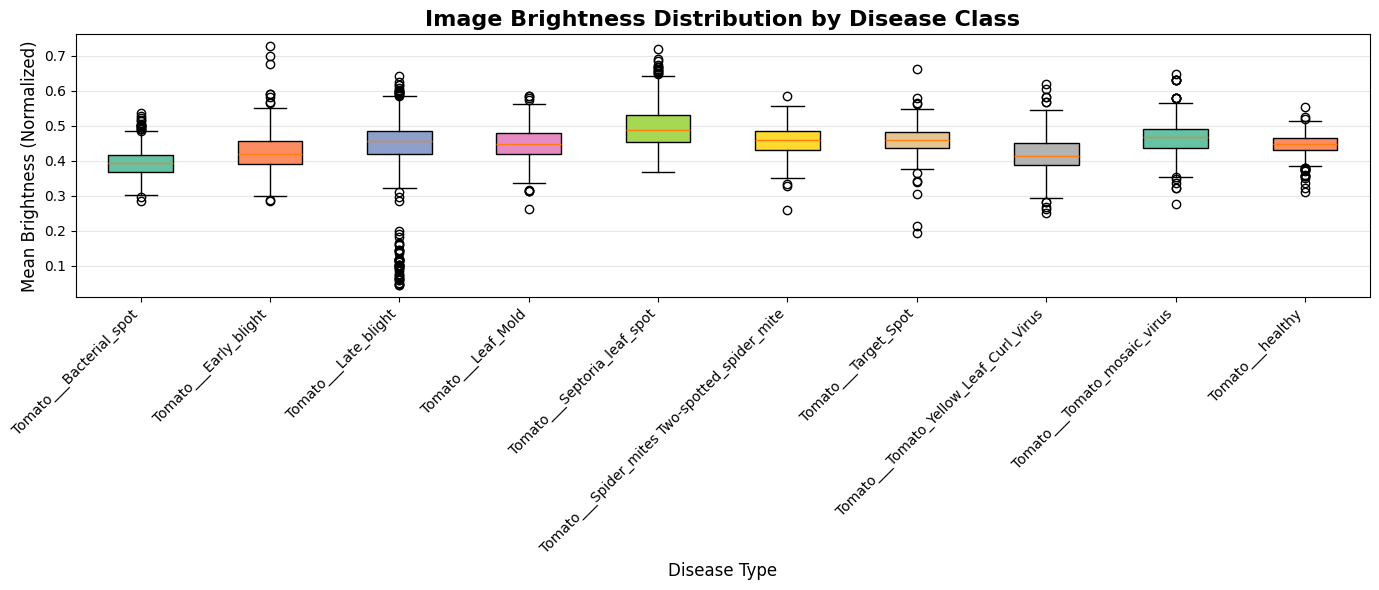

In [11]:
# Brightness analysis per class
brightness_by_class = {}

for encoded_label in unique_encoded_labels:
    class_indices = np.where(encoded_labels_train == encoded_label)[0]
    class_images = images_train_normalized[class_indices]
    # Calculate brightness as mean of all pixel values
    brightness = class_images.mean(axis=(1, 2, 3))
    disease_name = reverse_label_mapping[encoded_label]
    brightness_by_class[disease_name] = brightness

# Create boxplot
plt.figure(figsize=(14, 6))
box_data = [brightness_by_class[name] for name in brightness_by_class.keys()]
box = plt.boxplot(box_data, labels=brightness_by_class.keys(), patch_artist=True)

# Color the boxes
colors = sns.color_palette('Set2', len(box_data))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Image Brightness Distribution by Disease Class', fontsize=16, fontweight='bold')
plt.xlabel('Disease Type', fontsize=12)
plt.ylabel('Mean Brightness (Normalized)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Display dataset summary statistics
summary_data = {
    'Disease Class': list(disease_counts_train.index),
    'Training Samples': list(disease_counts_train.values),
    'Test Samples': list(disease_counts_test.values),
    'Total Samples': [train + test for train, test in zip(disease_counts_train.values, disease_counts_test.values)],
    'Train %': [f"{(train/(train+test)*100):.1f}%" for train, test in zip(disease_counts_train.values, disease_counts_test.values)]
}

summary_df = pd.DataFrame(summary_data)
print("=" * 100)
print("DATASET SUMMARY STATISTICS")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)
print(f"\nTotal Training Images: {disease_counts_train.sum()}")
print(f"Total Test Images: {disease_counts_test.sum()}")
print(f"Total Images: {disease_counts_train.sum() + disease_counts_test.sum()}")
print(f"Number of Classes: {len(disease_counts_train)}")
print(f"Average Images per Class (Train): {disease_counts_train.mean():.1f}")
print(f"Average Images per Class (Test): {disease_counts_test.mean():.1f}")

DATASET SUMMARY STATISTICS
                                Disease Class  Training Samples  Test Samples  Total Samples Train %
                      Tomato___Bacterial_spot               500           100            600   83.3%
                        Tomato___Early_blight               500           100            600   83.3%
                             Tomato___healthy               500           100            600   83.3%
                         Tomato___Late_blight               500           100            600   83.3%
                           Tomato___Leaf_Mold               500           100            600   83.3%
                  Tomato___Septoria_leaf_spot               500           100            600   83.3%
Tomato___Spider_mites Two-spotted_spider_mite               500           100            600   83.3%
                         Tomato___Target_Spot               500           100            600   83.3%
                 Tomato___Tomato_mosaic_virus               500 

-------------------------------------------------------------------------------------------------------

# Data Augmentation

### Task
Define PyTorch data augmentation transforms, create a custom PyTorch Dataset and DataLoaders for the existing `X_train`, `y_train`, `X_val`, and `y_val` data, visualize augmented images from the PyTorch DataLoader, and then explain the implications of using PyTorch augmentation with a Keras model, suggesting next steps.

### Visualize Multiple Sample Images Per Class

Let's visualize a grid of sample images for each class (both healthy and various disease types) to gain a better visual understanding of the dataset.

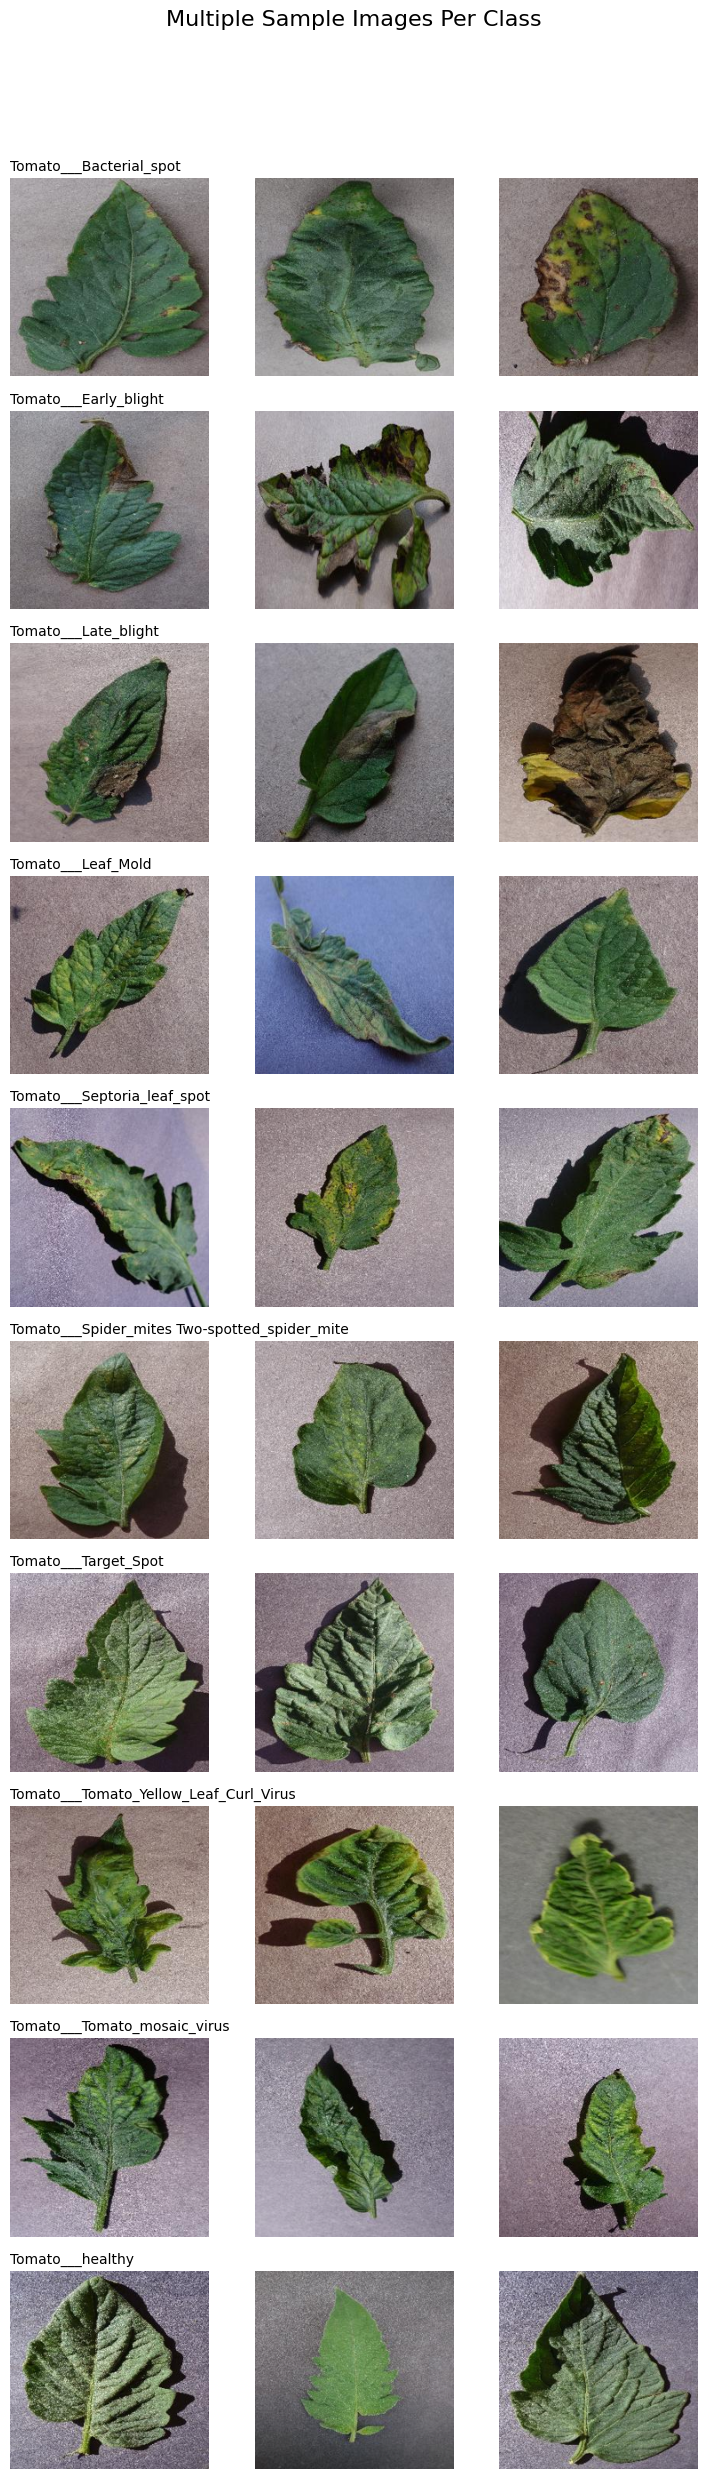

In [13]:
import matplotlib.pyplot as plt
import numpy as np

samples_per_class = 3 # Number of samples to display for each class

fig, axes = plt.subplots(num_diseases, samples_per_class, figsize=(samples_per_class * 2.5, num_diseases * 2.5))
fig.suptitle("Multiple Sample Images Per Class", fontsize=16, y=1.02)

for i, encoded_label in enumerate(unique_encoded_labels):
    # Get all indices for the current class
    class_indices = np.where(encoded_labels_train == encoded_label)[0]
    np.random.shuffle(class_indices) # Shuffle to get random samples

    # Get breed name for the title
    breed_name = reverse_label_mapping[encoded_label]

    for j in range(min(samples_per_class, len(class_indices))):
        idx = class_indices[j]
        image_to_show = images_train_normalized[idx]

        ax = axes[i, j]
        ax.imshow(image_to_show)
        ax.axis('off')
        if j == 0:
            ax.set_title(breed_name, fontsize=10, loc='left', wrap=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

### Calculate Mean and Standard Deviation of Training Images

Calculating the mean and standard deviation of the pixel values across your training dataset for each color channel is a crucial step for image normalization. These statistics are often used to standardize the input to deep learning models, which can lead to faster convergence and improved performance.

In [14]:
import numpy as np # Keep numpy as it's often useful, but not strictly for this calculation

# Calculate mean and std dev for each channel across the training set
# X_train is now a PyTorch tensor (num_images, channels, height, width) and already normalized to [0,1]
mean_per_channel = X_train.mean(dim=(0, 2, 3))
std_per_channel = X_train.std(dim=(0, 2, 3))

print(f"Mean per channel (R, G, B): {mean_per_channel}")
print(f"Standard Deviation per channel (R, G, B): {std_per_channel}")

print("\nThese values can be used for normalization during model training.")

Mean per channel (R, G, B): tensor([0.4519, 0.4626, 0.4183])
Standard Deviation per channel (R, G, B): tensor([0.1824, 0.1596, 0.1966])

These values can be used for normalization during model training.


## Define PyTorch Data Transforms

### Subtask:
Define the data augmentation transformations using `torchvision.transforms.Compose`. This will include operations like resizing, random horizontal flip, random rotation, color jitter, and converting images to PyTorch tensors.


**Reasoning**:
The subtask requires defining data augmentation transformations using `torchvision.transforms.Compose`. I need to import the `transforms` module and `torch`, then define both `train_transforms` with augmentation steps and `val_transforms` for validation/testing, and finally print them for verification.



In [15]:
import torch
from torchvision import transforms

# 1. Define train_transforms pipeline with data augmentation and normalization
train_transforms = transforms.Compose([
    transforms.ToPILImage(), # Convert image to PIL Image
    transforms.Resize((224, 224)), # Resize images to 224x224 (as done before)
    transforms.RandomHorizontalFlip(p=0.5), # Randomly flip the image horizontally
    transforms.RandomRotation(degrees=15), # Randomly rotate the image by up to 20 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Randomly change the brightness, contrast, saturation, and hue
    transforms.ToTensor(), # Convert image to PyTorch Tensor and normalize to [0, 1]
    transforms.Normalize(mean=mean_per_channel, std=std_per_channel) # Normalize with calculated mean and std
])

# 2. Define val_transforms pipeline for validation and testing (no augmentation, but with normalization)
val_transforms = transforms.Compose([
    transforms.ToPILImage(), # Convert image to PIL Image
    transforms.Resize((224, 224)), # Resize images to 224x224
    transforms.ToTensor(), # Convert image to PyTorch Tensor and normalize to [0, 1]
    transforms.Normalize(mean=mean_per_channel, std=std_per_channel) # Normalize with calculated mean and std
])

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader

# Define a custom Dataset class for our image data
class CustomImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images # Now expected to be PyTorch Tensors (N, C, H, W)
        self.labels = labels # Now expected to be PyTorch Tensors (N)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx] # Images are already PyTorch Tensors (C, H, W) in [0, 1]
        label = self.labels[idx] # Labels are already PyTorch Tensors

        if self.transform:
            # If the transform pipeline includes ToPILImage, it will convert the tensor to PIL Image
            # for augmentation, then ToTensor will convert it back to a tensor.
            image = self.transform(image)

        return image, label


# Create instances of the custom Dataset
train_dataset = CustomImageDataset(X_train, y_train, transform=train_transforms)
val_dataset = CustomImageDataset(X_val, y_val, transform=val_transforms)

# Define DataLoaders with GPU optimization
batch_size = 32 # Can be adjusted
# Use pin_memory=True for faster data transfer to GPU
# Reduce num_workers on Windows to avoid multiprocessing issues
use_cuda = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=0, pin_memory=use_cuda)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=use_cuda)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")

# Get one batch to verify shapes and types
for images, labels in train_loader:
    print("\nSample batch from train_loader:")
    print(f"Image batch shape: {images.shape}") # Expected: (batch_size, channels, height, width)
    print(f"Label batch shape: {labels.shape}") # Expected: (batch_size)
    print(f"Image data type: {images.dtype}")
    print(f"Label data type: {labels.dtype}")
    break

Number of training samples: 4000
Number of validation samples: 1000
Number of batches in training loader: 125
Number of batches in validation loader: 32

Sample batch from train_loader:
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64


**Reasoning**:
The previous step successfully created PyTorch DataLoaders. Now, I need to visualize some augmented images from the `train_loader` to confirm that the data augmentation transformations are being applied correctly and the data is in the expected format for PyTorch.



Shape of images batch: torch.Size([32, 3, 224, 224])
Shape of labels batch: torch.Size([32])


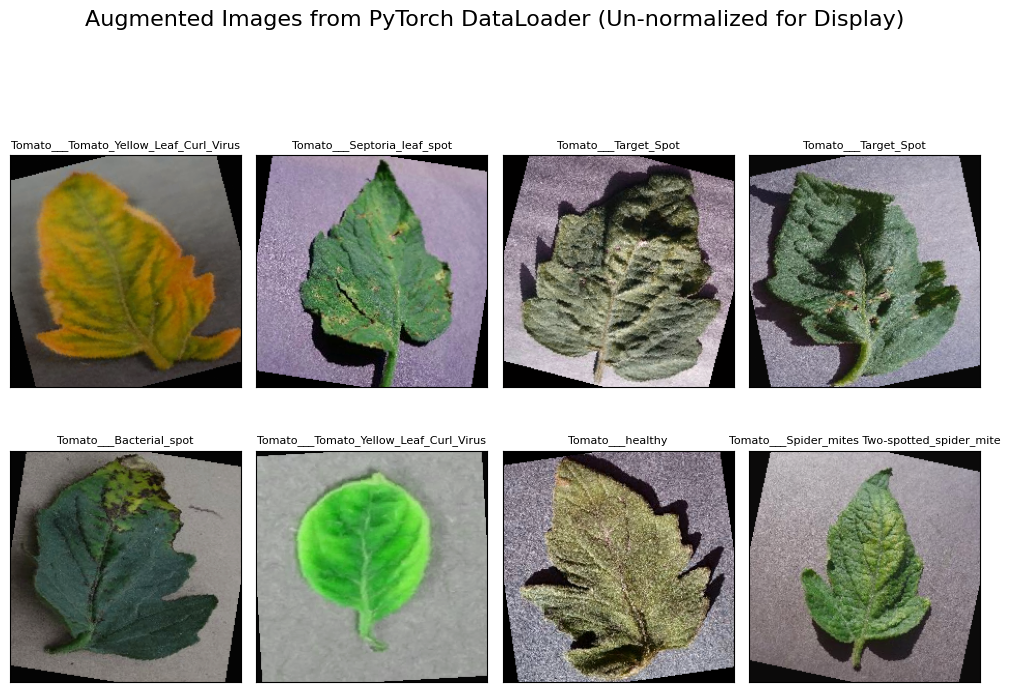

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of training data from the DataLoader
# We convert it to an iterator to get the next batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"Shape of images batch: {images.shape}") # Expected: (batch_size, channels, height, width)
print(f"Shape of labels batch: {labels.shape}")

# Visualize a few augmented images
fig = plt.figure(figsize=(10, 8))
for i in range(min(len(images), 8)): # Display up to 8 images
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])

    # Un-normalize the image for visualization
    # Images are C, H, W. Mean and std are 1D (C,). We need to reshape them for broadcasting
    mean = mean_per_channel.cpu().numpy()
    std = std_per_channel.cpu().numpy()

    img = images[i].cpu().numpy() # Convert to numpy array
    img = std[:, None, None] * img + mean[:, None, None] # Un-normalize

    # PyTorch images are (C, H, W), matplotlib expects (H, W, C)
    npimg = img.transpose((1, 2, 0))
    # Clamp values to [0, 1] as un-normalization might push them out, and imshow expects this range
    npimg = np.clip(npimg, 0, 1)
    ax.imshow(npimg)
    # Get original label name using reverse_label_mapping
    label_name = reverse_label_mapping[labels[i].item()]
    ax.set_title(label_name, fontsize=8)

plt.suptitle("Augmented Images from PyTorch DataLoader (Un-normalized for Display)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Build model MobileNetV2

In [18]:
import torch
import torch.nn as nn
from torchvision import models

def build_MobileNetV2(num_classes=10):
    model = models.mobilenet_v2(pretrained=True)

    # Freeze base
    for param in model.parameters():
        param.requires_grad = False

    # Get the input size of the original final layer (usually 1280)
    in_features = model.classifier[1].in_features

    # Replace the head
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, num_classes)
    )
    return model

MobileNetV2_model = build_MobileNetV2()
print("Model loaded successfully!")

Model loaded successfully!


/media/ubuntu/data_disk/Documents/itc_files/Year_04_Semester_01/AI/Project AI/Project_03/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/media/ubuntu/data_disk/Documents/itc_files/Year_04_Semester_01/AI/Project AI/Project_03/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [19]:
def build_EfficientNetB0(num_classes=10):
    model = models.efficientnet_b0(pretrained=True)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, num_classes) # EfficientNet often performs best with a simpler head
    )
    return model

# Instantiate
effnet_model = build_EfficientNetB0(num_classes=4)
print(effnet_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


/media/ubuntu/data_disk/Documents/itc_files/Year_04_Semester_01/AI/Project AI/Project_03/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [20]:
def build_simple_cnn(num_classes=10):
    model = nn.Sequential(
        # Block 1: Input (3, 224, 224) -> (32, 111, 111)
        nn.Conv2d(3, 32, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        # Block 2: (32, 111, 111) -> (64, 54, 54)
        nn.Conv2d(32, 64, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        # Block 3: (64, 54, 54) -> (128, 26, 26)
        nn.Conv2d(64, 128, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Flatten(),

        # Calculation: 128 channels * 26 * 26 spatial size = 86528
        nn.Linear(128 * 26 * 26, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, num_classes)
        # NOTE: CrossEntropyLoss in PyTorch already includes Softmax.
        # Adding it here would be redundant and potentially harmful.
    )
    return model

# Instantiate
simple_cnn = build_simple_cnn(num_classes=10)
print(simple_cnn)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=86528, out_features=128, bias=True)
  (11): ReLU()
  (12): Dropout(p=0.5, inplace=False)
  (13): Linear(in_features=128, out_features=10, bias=True)
)


In [21]:
def build_DenseNet121(num_classes=10):
    model = models.densenet121(pretrained=True)
    
    # Freeze base layers
    for param in model.parameters():
        param.requires_grad = False
    
    # Get the input features of the classifier
    in_features = model.classifier.in_features
    
    # Replace the classifier head
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes)
    )
    return model

# Instantiate
densenet_model = build_DenseNet121(num_classes=10)
print("DenseNet121 model created successfully!")
print(densenet_model.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


/media/ubuntu/data_disk/Documents/itc_files/Year_04_Semester_01/AI/Project AI/Project_03/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 30.8M/30.8M [00:10<00:00, 3.13MB/s]

DenseNet121 model created successfully!
Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=10, bias=True)
)


## Setup for training

Create DataLoaders

In [22]:
from torch.utils.data import DataLoader, TensorDataset

# 1. Wrap tensors into a Dataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# 2. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

The PyTorch Training Function

In [23]:
from tqdm.auto import tqdm # Progress bar library

def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        # --- Add tqdm here for the progress bar ---
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Update the progress bar with current loss/acc
            train_bar.set_postfix(loss=loss.item(), acc=f"{(100.*correct/total):.2f}%")

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        # Save metrics
        history['train_loss'].append(running_loss/len(train_loader))
        history['train_acc'].append(100.*correct/total)
        history['val_loss'].append(val_loss/len(val_loader))
        history['val_acc'].append(100.*val_correct/val_total)

        print(f"Summary - Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

Run Training on Model MobileNetV2

In [24]:
# MobileNetV2
model_mobilenetv2 = build_EfficientNetB0(num_classes=10)

# Start training
history_mobilenet = train_model(model_mobilenetv2, train_loader, val_loader, epochs=10)

/media/ubuntu/data_disk/Documents/itc_files/Year_04_Semester_01/AI/Project AI/Project_03/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/media/ubuntu/data_disk/Documents/itc_files/Year_04_Semester_01/AI/Project AI/Project_03/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 69.25% | Val Acc: 80.40%


Epoch 2/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 92.35% | Val Acc: 90.80%


Epoch 10/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 92.55% | Val Acc: 91.30%


In [25]:
# EfficientNetB0
model_EfficientNetB0 = build_EfficientNetB0(num_classes=10)

# Start training
history_efficientnet = train_model(model_EfficientNetB0, train_loader, val_loader, epochs=10)

Epoch 1/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 69.25% | Val Acc: 80.50%


Epoch 2/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 92.05% | Val Acc: 91.80%


Epoch 10/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 92.70% | Val Acc: 92.00%


In [26]:
# Custom CNN
model_simple_cnn = build_simple_cnn(num_classes=10)

# Start training
history_cnn = train_model(model_simple_cnn, train_loader, val_loader, epochs=20)

Epoch 1/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 35.67% | Val Acc: 59.80%


Epoch 2/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 93.53% | Val Acc: 86.80%


Epoch 20/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 93.92% | Val Acc: 82.80%


In [27]:
# DenseNet121
model_densenet121 = build_DenseNet121(num_classes=10)

# Start training
history_densenet = train_model(model_densenet121, train_loader, val_loader, epochs=10)

/media/ubuntu/data_disk/Documents/itc_files/Year_04_Semester_01/AI/Project AI/Project_03/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 56.73% | Val Acc: 84.20%


Epoch 2/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 92.03% | Val Acc: 92.30%


Epoch 10/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Summary - Train Acc: 92.33% | Val Acc: 93.30%


## Visualize Training History

In [28]:
def plot_training_history(history, model_name='Model'):
    """
    Plot training and validation loss and accuracy curves
    
    Args:
        history: Dictionary with keys 'train_loss', 'train_acc', 'val_loss', 'val_acc'
        model_name: Name of the model for the plot title
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Plot Loss
    ax1.plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    ax1.set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print(f"\n{model_name} - Final Metrics:")
    print(f"  Training Loss: {history['train_loss'][-1]:.4f} | Training Acc: {history['train_acc'][-1]:.2f}%")
    print(f"  Validation Loss: {history['val_loss'][-1]:.4f} | Validation Acc: {history['val_acc'][-1]:.2f}%")

### MobileNetV2 Training History

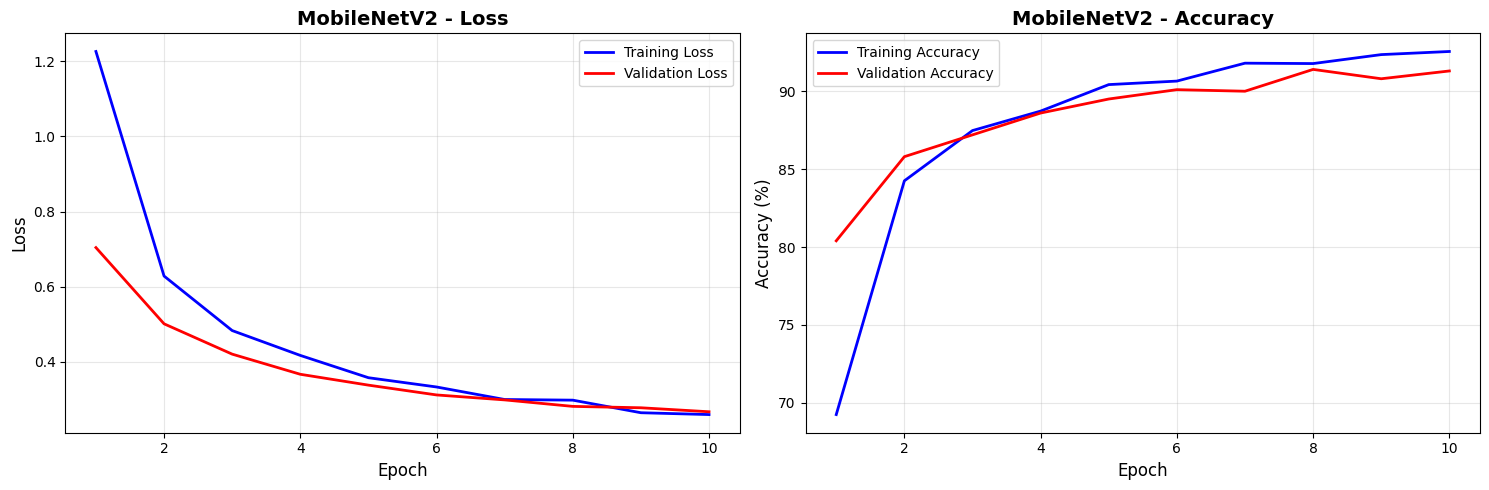


MobileNetV2 - Final Metrics:
  Training Loss: 0.2600 | Training Acc: 92.55%
  Validation Loss: 0.2675 | Validation Acc: 91.30%


In [29]:
plot_training_history(history_mobilenet, 'MobileNetV2')

### EfficientNetB0 Training History

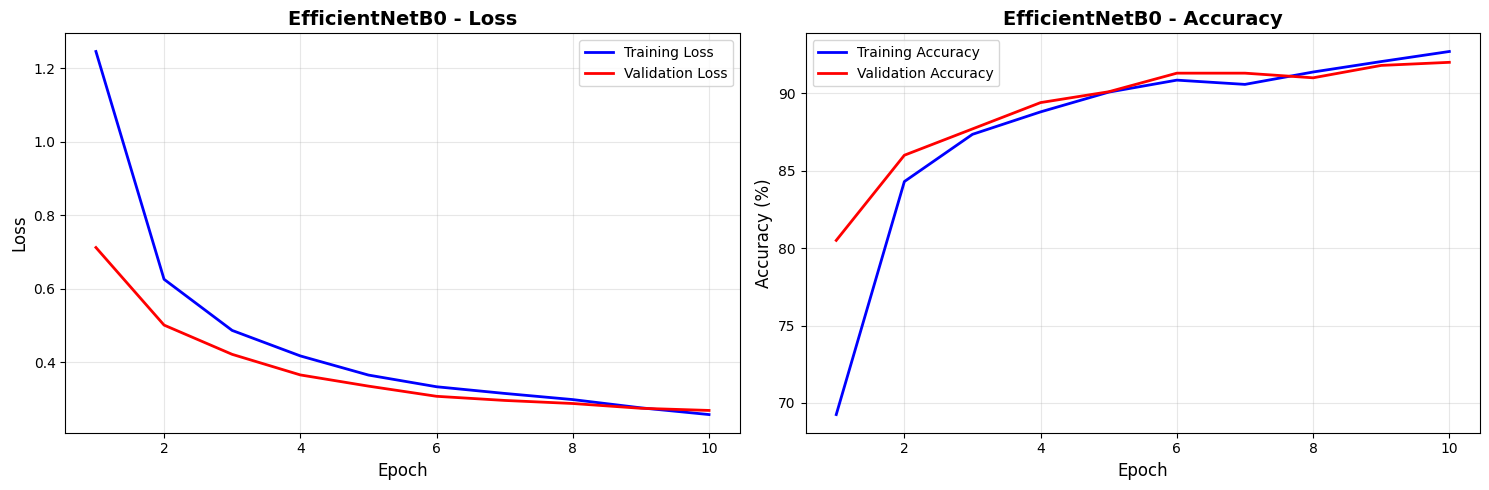


EfficientNetB0 - Final Metrics:
  Training Loss: 0.2577 | Training Acc: 92.70%
  Validation Loss: 0.2689 | Validation Acc: 92.00%


In [30]:
plot_training_history(history_efficientnet, 'EfficientNetB0')

### Custom CNN Training History

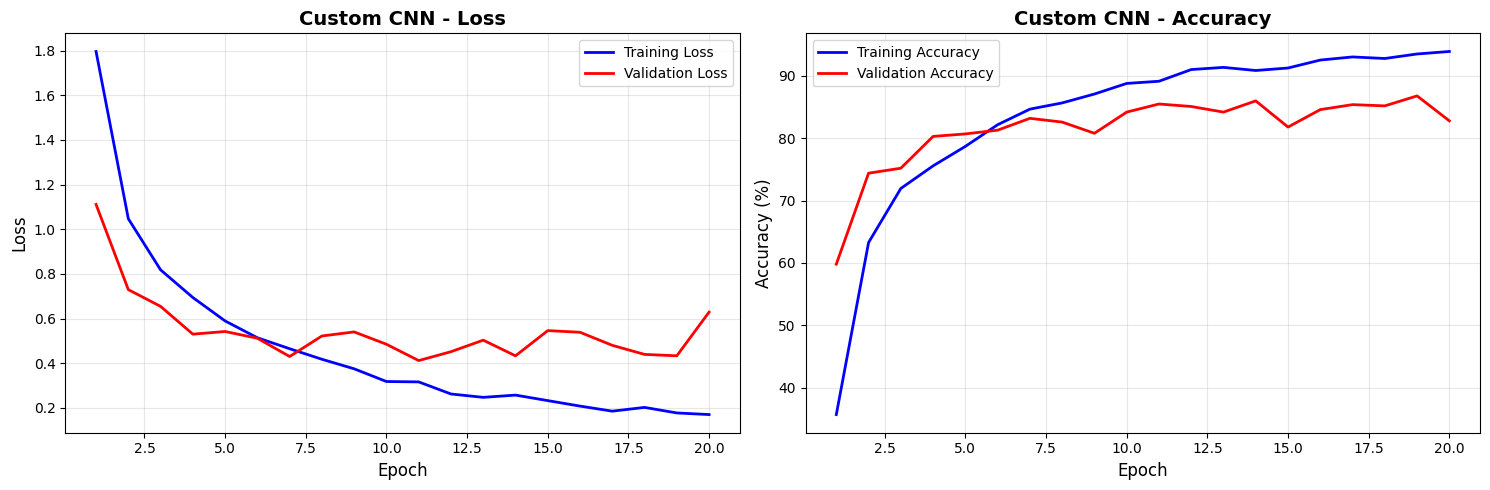


Custom CNN - Final Metrics:
  Training Loss: 0.1702 | Training Acc: 93.92%
  Validation Loss: 0.6292 | Validation Acc: 82.80%


In [31]:
plot_training_history(history_cnn, 'Custom CNN')

## Save All Models

In [39]:
import os

# Create a directory to save models
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)

# Save all models
model_dict = {
    'mobilenetv2': model_mobilenetv2,
    'efficientnetb0': model_EfficientNetB0,
    'simple_cnn': model_simple_cnn,
    'densenet121': model_densenet121
}

history_dict = {
    'mobilenetv2': history_mobilenet,
    'efficientnetb0': history_efficientnet,
    'simple_cnn': history_cnn,
    'densenet121': history_densenet
}

# Save each model
for model_name, model in model_dict.items():
    model_path = os.path.join(save_dir, f'{model_name}_model.pth')
    torch.save(model.state_dict(), model_path)
    print(f'✓ Saved {model_name} model to {model_path}')

# Save training histories
import pickle
for model_name, history in history_dict.items():
    history_path = os.path.join(save_dir, f'{model_name}_history.pkl')
    with open(history_path, 'wb') as f:
        pickle.dump(history, f)
    print(f'✓ Saved {model_name} training history to {history_path}')

print(f'\n✓ All models and training histories saved successfully in {save_dir}/ directory!')

✓ Saved mobilenetv2 model to saved_models/mobilenetv2_model.pth
✓ Saved efficientnetb0 model to saved_models/efficientnetb0_model.pth
✓ Saved simple_cnn model to saved_models/simple_cnn_model.pth
✓ Saved densenet121 model to saved_models/densenet121_model.pth
✓ Saved mobilenetv2 training history to saved_models/mobilenetv2_history.pkl
✓ Saved efficientnetb0 training history to saved_models/efficientnetb0_history.pkl
✓ Saved simple_cnn training history to saved_models/simple_cnn_history.pkl
✓ Saved densenet121 training history to saved_models/densenet121_history.pkl

✓ All models and training histories saved successfully in saved_models/ directory!


### DenseNet121 Training History

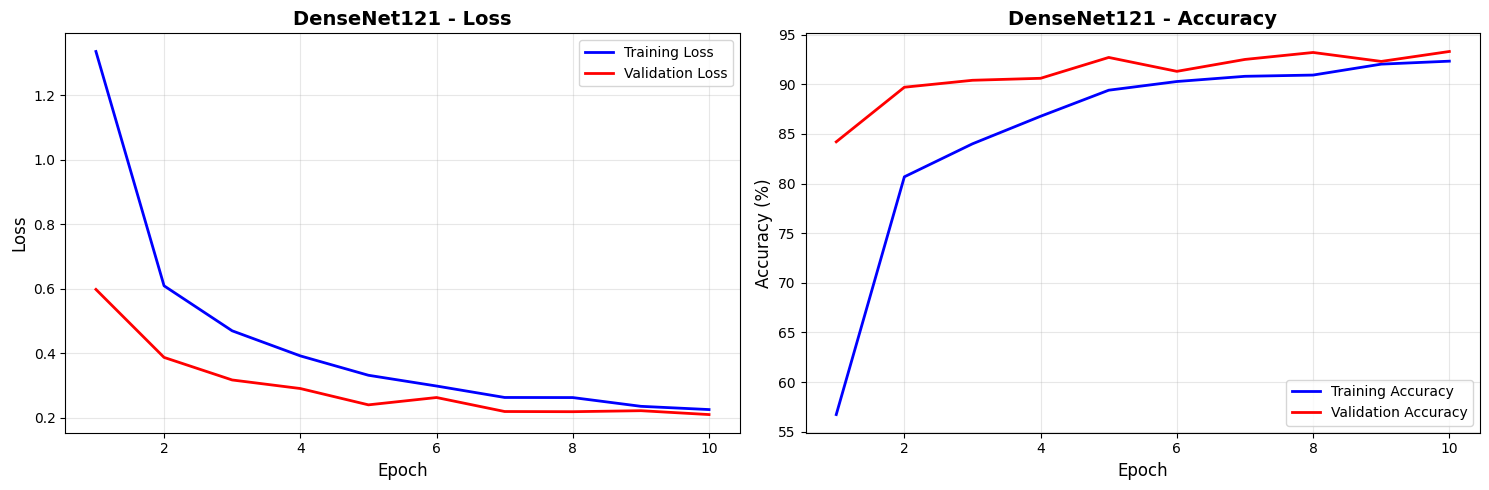


DenseNet121 - Final Metrics:
  Training Loss: 0.2261 | Training Acc: 92.33%
  Validation Loss: 0.2106 | Validation Acc: 93.30%


In [32]:
plot_training_history(history_densenet, 'DenseNet121')

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, test_loader, target_names):
    model.eval()
    all_preds = []
    all_labels = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 1. Print Accuracy and Detailed Metrics
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # 2. Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Tomato Disease Detection')
    plt.show()

    return all_labels, all_preds

## Model Evaluation with Confusion Matrix

Create evaluation function that generates classification report and confusion matrix for each model

In [34]:
# Prepare Test Loader
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Get Disease Names from your LabelEncoder
disease_names = list(label_encoder.classes_)


--- Classification Report ---
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.90      0.94      0.92       100
                        Tomato___Early_blight       0.88      0.80      0.84       100
                         Tomato___Late_blight       0.90      0.85      0.88       100
                           Tomato___Leaf_Mold       0.95      0.92      0.93       100
                  Tomato___Septoria_leaf_spot       0.87      0.88      0.88       100
Tomato___Spider_mites Two-spotted_spider_mite       0.94      0.85      0.89       100
                         Tomato___Target_Spot       0.83      0.89      0.86       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.94      0.96      0.95       100
                 Tomato___Tomato_mosaic_virus       0.93      0.99      0.96       100
                             Tomato___healthy       0.93      1.00      0.97       100

          

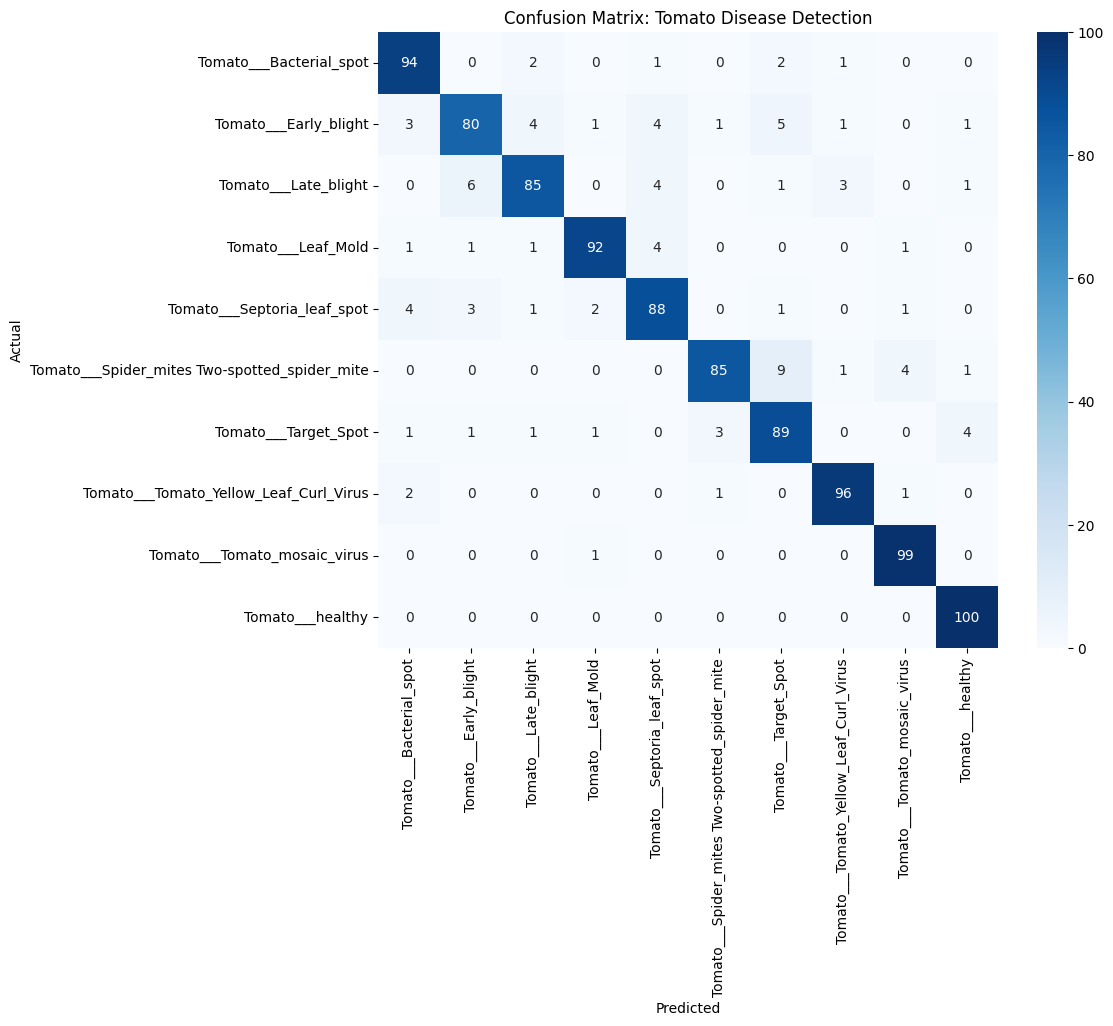

In [35]:
# Run Evaluation (model MobileNetV2)
y_true, y_pred = evaluate_model(model_mobilenetv2, test_loader, disease_names)


--- Classification Report ---
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.86      0.96      0.91       100
                        Tomato___Early_blight       0.89      0.82      0.85       100
                         Tomato___Late_blight       0.91      0.83      0.87       100
                           Tomato___Leaf_Mold       0.91      0.94      0.93       100
                  Tomato___Septoria_leaf_spot       0.92      0.87      0.89       100
Tomato___Spider_mites Two-spotted_spider_mite       0.97      0.86      0.91       100
                         Tomato___Target_Spot       0.85      0.91      0.88       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.94      0.94      0.94       100
                 Tomato___Tomato_mosaic_virus       0.93      0.99      0.96       100
                             Tomato___healthy       0.95      0.99      0.97       100

          

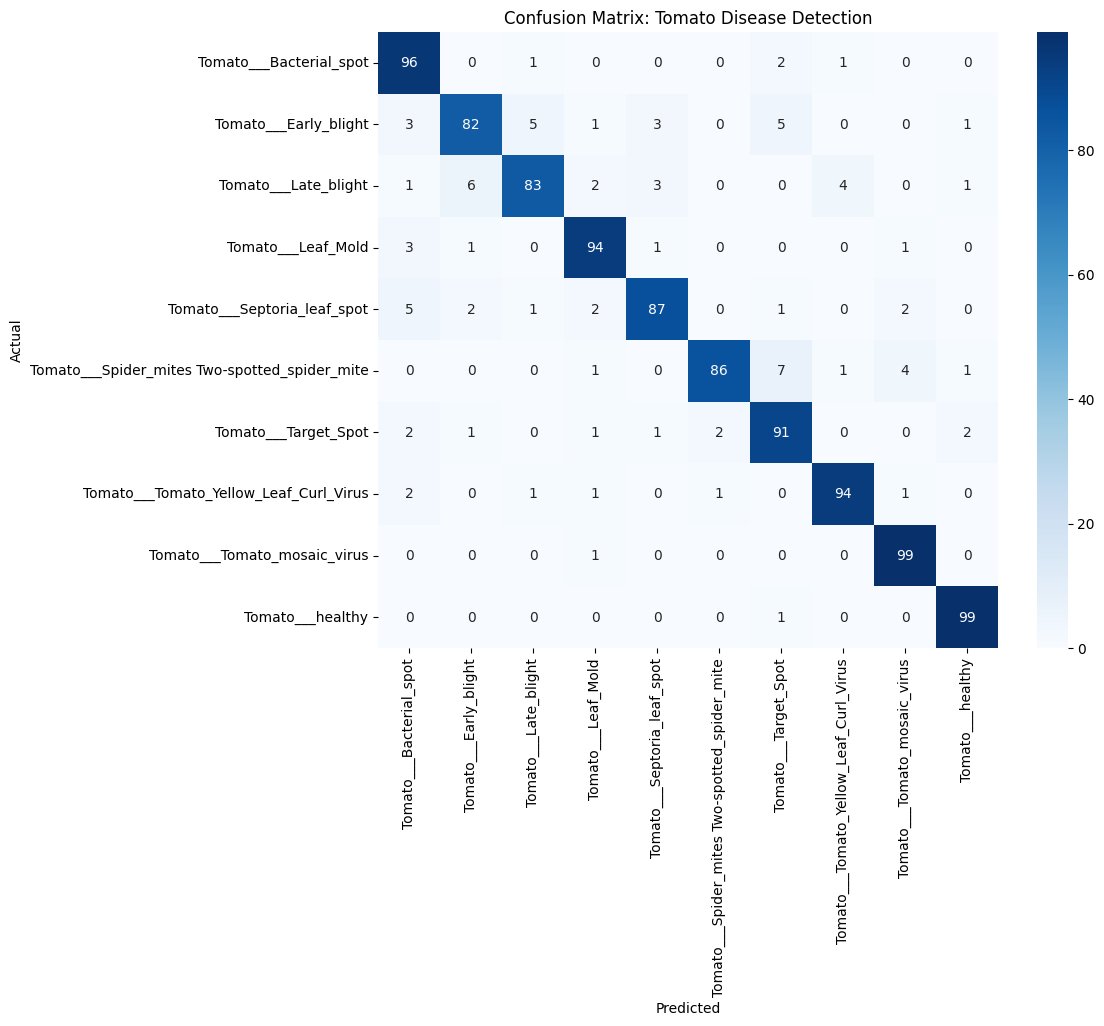

In [36]:
# Run Evaluation (model EfficientNetB0)
y_true, y_pred = evaluate_model(model_EfficientNetB0, test_loader, disease_names)


--- Classification Report ---
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.90      0.87      0.88       100
                        Tomato___Early_blight       0.63      0.85      0.72       100
                         Tomato___Late_blight       0.89      0.72      0.80       100
                           Tomato___Leaf_Mold       0.82      0.79      0.81       100
                  Tomato___Septoria_leaf_spot       0.80      0.69      0.74       100
Tomato___Spider_mites Two-spotted_spider_mite       0.84      0.87      0.86       100
                         Tomato___Target_Spot       0.78      0.76      0.77       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.83      0.93      0.88       100
                 Tomato___Tomato_mosaic_virus       0.90      0.94      0.92       100
                             Tomato___healthy       0.97      0.86      0.91       100

          

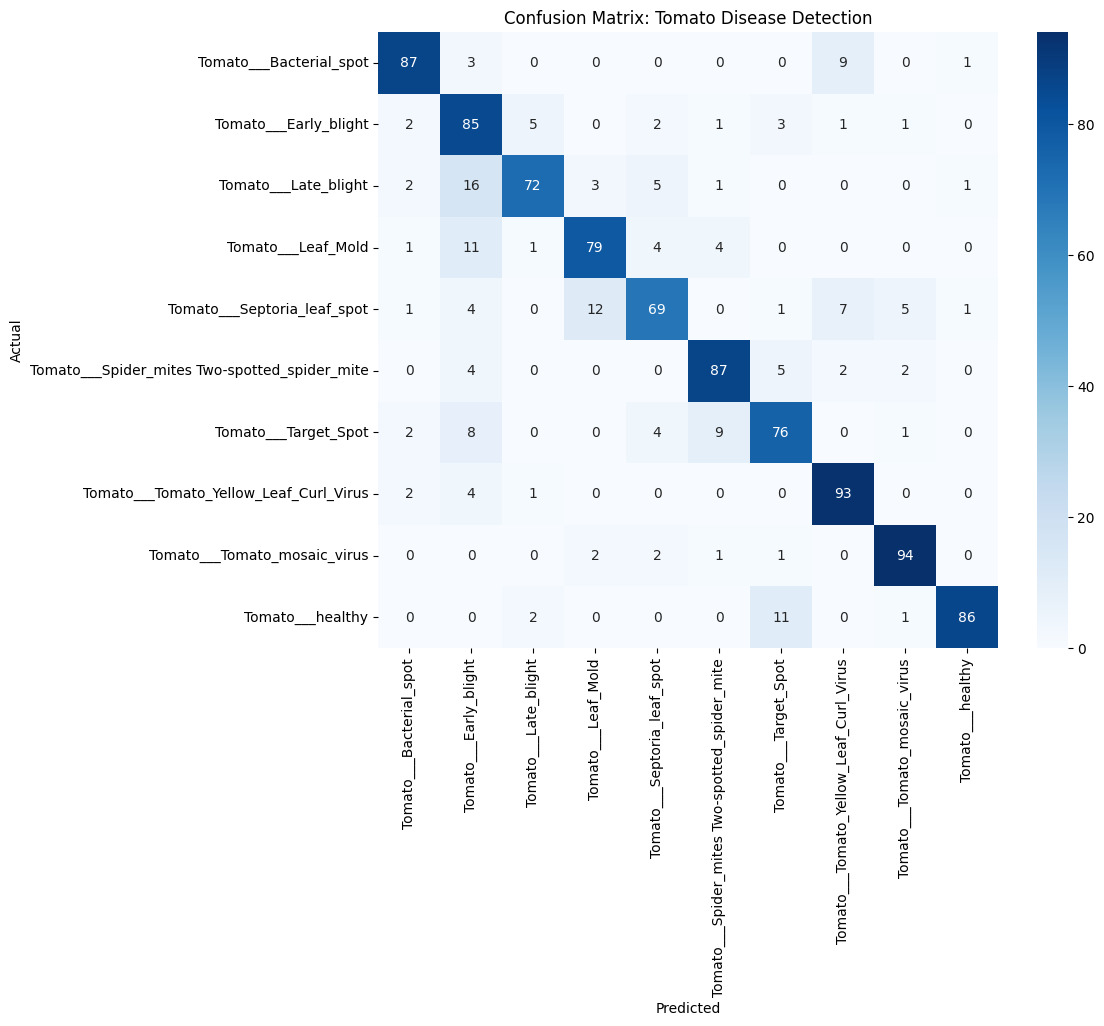

In [37]:
# Run Evaluation (model Custom CNN)
y_true, y_pred = evaluate_model(model_simple_cnn, test_loader, disease_names)


--- Classification Report ---
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.93      0.94      0.94       100
                        Tomato___Early_blight       0.87      0.89      0.88       100
                         Tomato___Late_blight       0.89      0.90      0.90       100
                           Tomato___Leaf_Mold       0.97      0.94      0.95       100
                  Tomato___Septoria_leaf_spot       0.95      0.87      0.91       100
Tomato___Spider_mites Two-spotted_spider_mite       0.92      0.93      0.93       100
                         Tomato___Target_Spot       0.91      0.95      0.93       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.95      0.97       100
                 Tomato___Tomato_mosaic_virus       0.94      1.00      0.97       100
                             Tomato___healthy       0.98      0.99      0.99       100

          

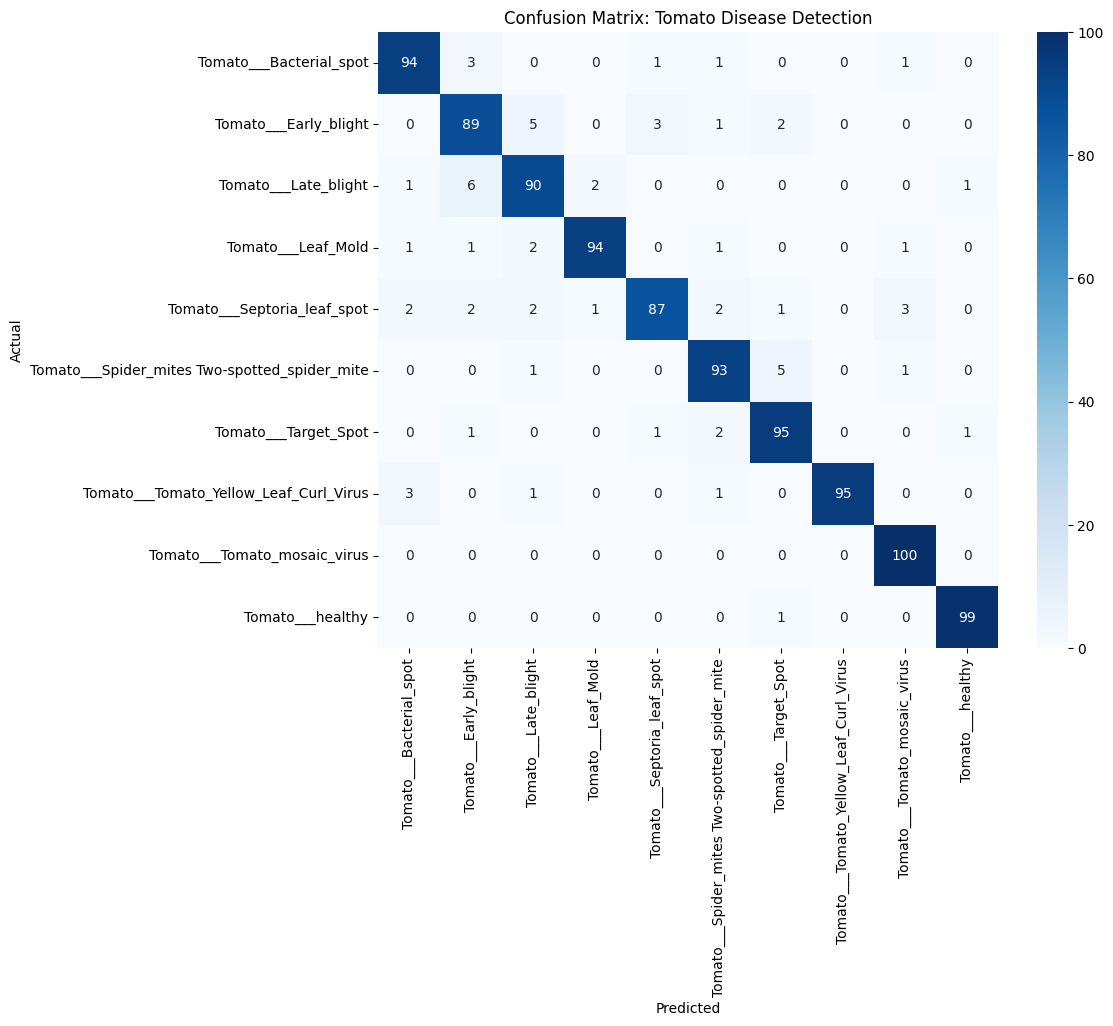

In [38]:
# Run Evaluation (model DenseNet121)
y_true, y_pred = evaluate_model(model_densenet121, test_loader, disease_names)